<a href="https://colab.research.google.com/github/JyRaGa/CS303-Machine-Learning_Coursework/blob/main/lab3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CS303 Machine Learning Lab
## Experiment 3: Data Preprocessing, Pipelines and Leakage Detection
### (24/CS/232)

**1. Loading the Dataset & Identifying Features**

In [ ]:
# import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings('ignore')

# load the dataset
df = pd.read_csv('Titanic-Dataset.csv')

# drop columns that act as identifiers or contain unstructured text
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'])

# display data information to identify numerical and categorical features
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


**Problem Formulation:**
* **Numerical Features:** `Age`, `Fare`, `SibSp`, `Parch`
* **Categorical Features:** `Pclass` (ordinal, treated as categorical here), `Sex`, `Embarked`
* **Target:** `Survived`

The objective is to predict survival. If statistics (such as the mean for missing values or standard deviation for scaling) are calculated on the *entire* dataset before splitting, information from the test set 'leaks' into the training process. This produces artificially optimistic test scores.

**2. Leaky Implementation 1: Scaling Before Splitting**

In this flawed implementation, the dataset is scaled *before* being split into training and testing sets.

In [ ]:
# drop null rows for the scaling example to prevent errors
df_leaky1 = df.dropna().copy()

# separate features and target variables
X_leak1 = df_leaky1.drop('Survived', axis=1)
y_leak1 = df_leaky1['Survived']

# encode categorical text into numerical format for scaling
X_leak1 = pd.get_dummies(X_leak1, columns=['Sex', 'Embarked'], drop_first=True)

# FLAW: scaling the entire dataset before splitting
scaler = StandardScaler()
X_scaled_leak1 = scaler.fit_transform(X_leak1)

# split the already scaled data (70:30 ratio)
X_train_l1, X_test_l1, y_train_l1, y_test_l1 = train_test_split(X_scaled_leak1, y_leak1, test_size=0.30, random_state=42)

# train and evaluate the model
model_l1 = LogisticRegression()
model_l1.fit(X_train_l1, y_train_l1)
acc_leak1 = accuracy_score(y_test_l1, model_l1.predict(X_test_l1))

print("Accuracy with scaling leakage:", round(acc_leak1, 4))

Accuracy with scaling leakage: 0.7991


**3. Correct Implementation: Using Scikit-Learn Pipelines**

To prevent leakage, the dataset must be split *first*. Then, a `Pipeline` and `ColumnTransformer` are utilized to ensure preprocessing is fitted *only* on the training data.

In [ ]:
# fresh data separation
X = df.drop('Survived', axis=1)
y = df['Survived']

# CORRECT: split the raw data BEFORE any preprocessing
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X, y, test_size=0.30, random_state=42)

# define which columns require which preprocessing
numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
categorical_features = ['Sex', 'Embarked']

# create a transformer for numbers (fill missing with mean, then scale)
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# create a transformer for categories (fill missing with most frequent, then one-hot encode)
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# combine both transformers into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# create the final pipeline with the preprocessor and the machine learning model
correct_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])

# fit the pipeline strictly on the training data
correct_pipeline.fit(X_train_c, y_train_c)

# evaluate on the test dataset
acc_correct = accuracy_score(y_test_c, correct_pipeline.predict(X_test_c))

print("Accuracy with correct pipeline:", round(acc_correct, 4))

Accuracy with correct pipeline: 0.8097


**4. Leaky Implementation 2: Imputation Before Splitting**

Another major source of leakage occurs when calculating statistics (such as the mean to fill missing `NaN` values) using the entire dataset, rather than isolating the calculation to the training data.

In [ ]:
df_leaky2 = df.copy()

# FLAW: calculate the mean age using the whole dataset (including future test rows)
global_mean_age = df_leaky2['Age'].mean()
df_leaky2['Age'] = df_leaky2['Age'].fillna(global_mean_age)

# separate and split data after the leaky imputation
X_leak2 = df_leaky2.drop('Survived', axis=1)
y_leak2 = df_leaky2['Survived']
X_train_l2, X_test_l2, y_train_l2, y_test_l2 = train_test_split(X_leak2, y_leak2, test_size=0.30, random_state=42)

# set up a pipeline for the remaining steps (scaling and encoding)
preprocessor_l2 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features)
    ])

pipe_l2 = Pipeline(steps=[
    ('preprocessor', preprocessor_l2),
    ('classifier', LogisticRegression(max_iter=1000))
])

pipe_l2.fit(X_train_l2, y_train_l2)
acc_leak2 = accuracy_score(y_test_l2, pipe_l2.predict(X_test_l2))

print("Accuracy with imputation leakage:", round(acc_leak2, 4))

Accuracy with imputation leakage: 0.8097


**5. Visualization of Pipeline Performance**

Visual comparison of accuracy metrics generated by the flawed implementations versus the correctly isolated pipeline.

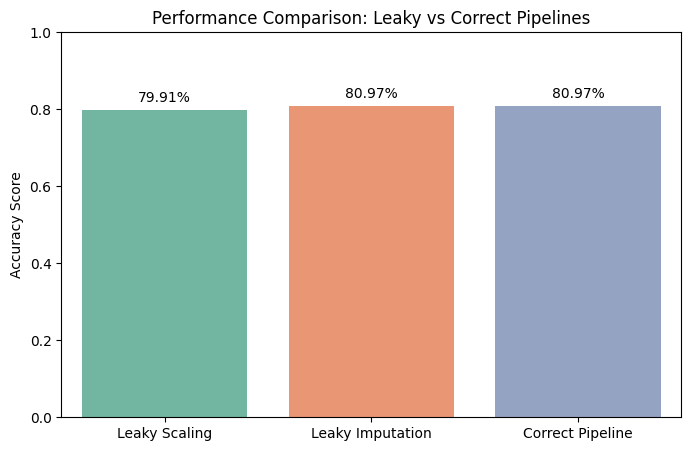

In [ ]:
# set up lists for plotting
pipelines = ['Leaky Scaling', 'Leaky Imputation', 'Correct Pipeline']
accuracies = [acc_leak1, acc_leak2, acc_correct]

# configure the figure size
plt.figure(figsize=(8, 5))

# generate a bar plot using seaborn
ax = sns.barplot(x=pipelines, y=accuracies, palette='Set2')
plt.ylim(0, 1.0)
plt.title('Performance Comparison: Leaky vs Correct Pipelines')
plt.ylabel('Accuracy Score')

# add percentage labels above each bar for clarity
for i, v in enumerate(accuracies):
    ax.text(i, v + 0.02, f"{v:.2%}", ha='center')

# display the plot
plt.show()

**6. Observations & Conclusion**

* **Analysis of Results:** Based on the visualization, the Leaky Scaling pipeline yielded an accuracy of 79.91%, while both the Leaky Imputation and the Correct Pipeline achieved 80.97%.
* **Scaling Leakage:** In the flawed scaling implementation, `StandardScaler` was fitted on the entire dataset before the train-test split. Interestingly, the accuracy dropped to 79.91%. While data leakage is often assumed to artificially inflate scores, it fundamentally distorts the feature space. Using global statistics alters how the test data is projected, which can occasionally degrade performance depending on the data distribution and the model's decision boundary.
* **Imputation Leakage:** Calculating the mean age on the whole dataset resulted in an identical accuracy (80.97%) to the correct pipeline. This indicates that the global mean age was extremely close to the training set's mean age, meaning the leakage was not severe enough to shift test predictions in this specific run.
* **The Correct Approach:** Even when leaky pipelines perform similarly or worse, their results are inherently invalid because they violate the strict separation of training and testing data. The Correct Pipeline, utilizing Scikit-learn's `Pipeline` to constrain `fit()` processes strictly to `X_train`, provides the only reliable and scientifically sound estimate of real-world performance (80.97%).
* **General Rule:** A dataset must always be split into training and testing subsets *before* applying any data transformations. Any step that calculates an overarching statistic (mean, standard deviation, mode) must only learn from the training data.